In [1]:
import pandas as pd
from rdkit.Chem import PandasTools
import pickle 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split, KFold



import shap
import numpy as np

import pickle

ModuleNotFoundError: No module named 'shap'

In [8]:
from dielectric_ml import chemnet, fionet, plotnet, neurnet, prednet

In [14]:
# load fprints and get targets
with open('new_de_fps.pkl', 'rb') as f:
    fprints = pickle.load(f)

In [15]:
file_path = 'new_DE_data.xlsx'
df = pd.read_excel(file_path)

# Convert to numeric and drop invalid rows (do this once)
df['target'] = pd.to_numeric(df['Δε'], errors='coerce')
df = df.dropna(subset=['target']).reset_index(drop=True)
target = df['target']

print(f"Retained {len(df)} samples")

PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
pd.set_option('display.max_rows', 10)

Retained 3135 samples


In [16]:
# select fingerprints

fprints = fprints["mordred_fingerprint"]

In [17]:
fprints, target = chemnet.clean_fprints_targets(fprints, target)

In [20]:
target

array([  9.7 ,  10.5 ,  17.  , ..., -14.5 ,  -9.37,  -8.74], shape=(3135,))

In [18]:
print(len(target)), print(len(fprints))

3135
3135


(None, None)

In [31]:
target

array([  9.7 ,  10.5 ,  17.  , ..., -14.5 ,  -9.37,  -8.74], shape=(3135,))

**TRAIN THE MODEL YOU WISH TO EXPLAIN**

In [21]:
layers_config = [
    (nn.Linear, {'out_size': 32}),
    (nn.ReLU, {}),
    (nn.Dropout, {'p': 0.15}),
    (nn.Linear, {'out_size':16}),
    (nn.ReLU, {}),
]

model = neurnet.create_simple_model(input_data=fprints,
                            layer_config=layers_config,
                            output_size=1)

In [22]:
from skfp.fingerprints import MordredFingerprint
from rdkit import Chem

mfp = MordredFingerprint()
# You need to fit it on molecules to get the names
mol = Chem.MolFromSmiles(gen["smiles"][0])
mfp.fit([mol])  # mols = your list of RDKit mol objects
descriptor_names = mfp.get_feature_names_out()

Using default optim.Adam optimiser
Fold 1
Early stopping at epoch 54/500 (patience=25)


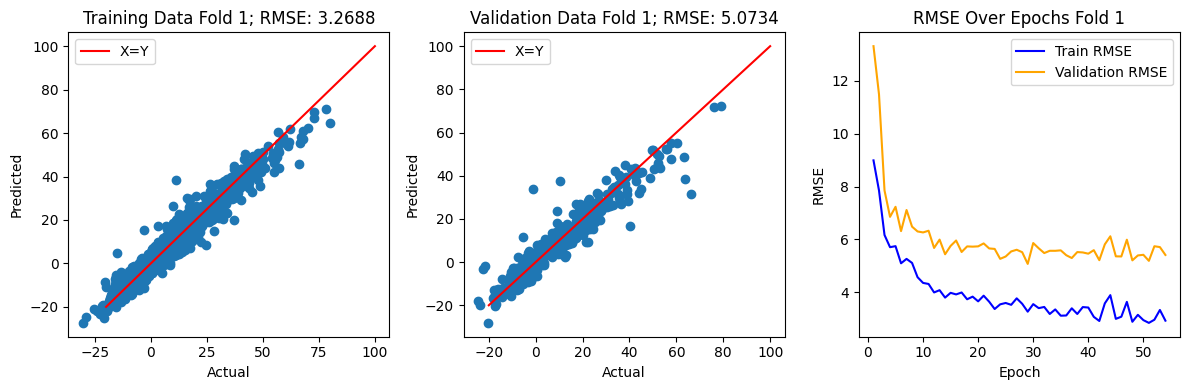

Fold 2
Early stopping at epoch 70/500 (patience=25)


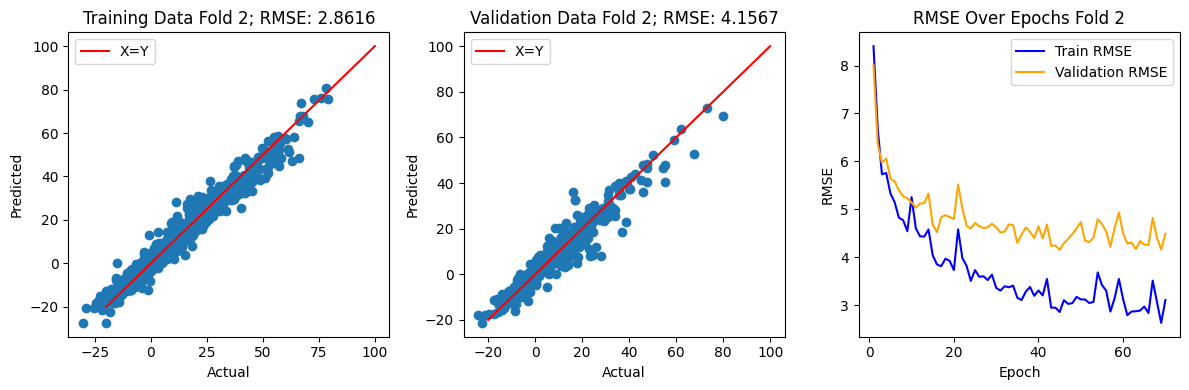

Fold 3
Early stopping at epoch 59/500 (patience=25)


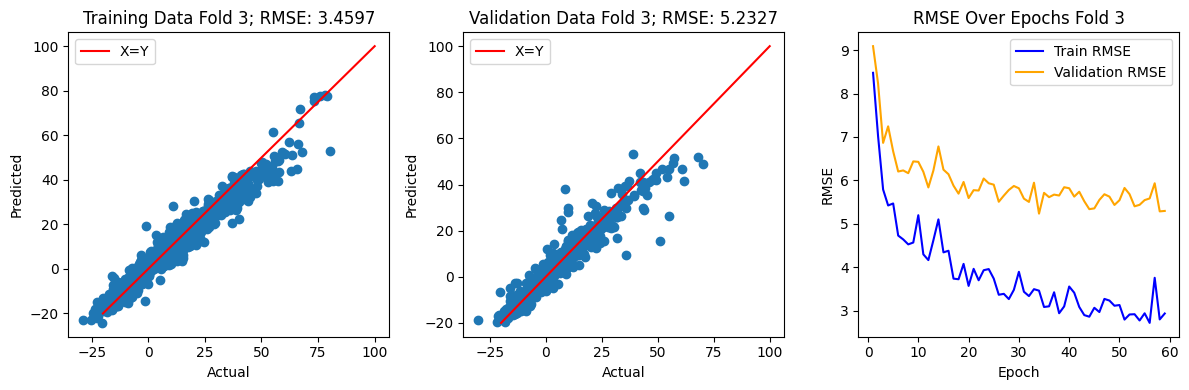

Fold 4
Early stopping at epoch 69/500 (patience=25)


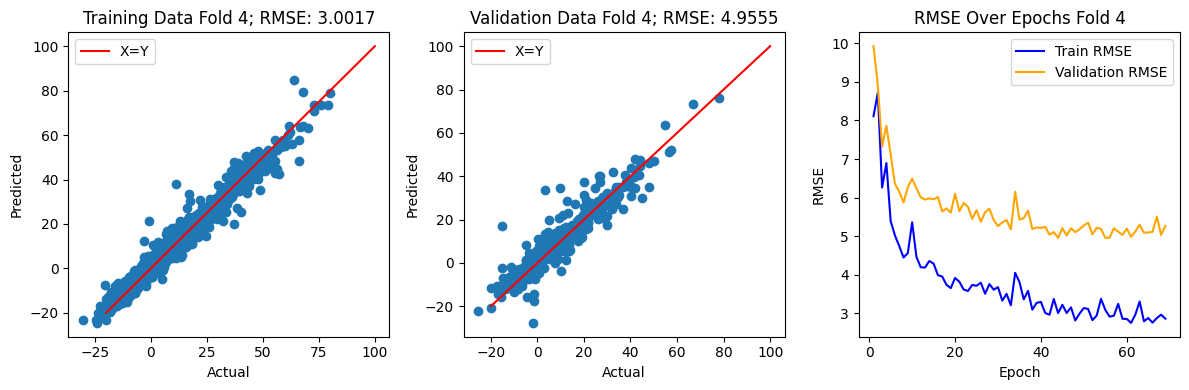

Fold 5
Early stopping at epoch 91/500 (patience=25)


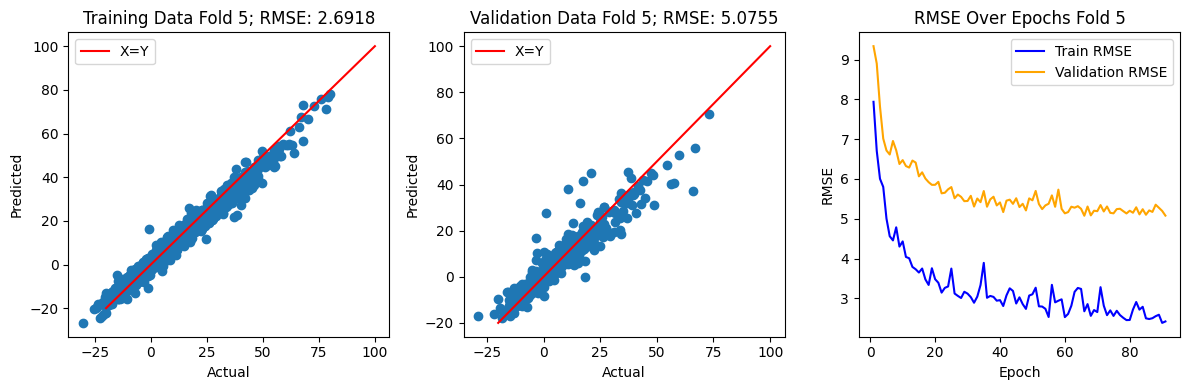

Validation RMSE across folds: mean=4.8987 ± 0.4264 (n=5)
Final holdout test set RMSE with best model (from fold 2) has RMSE: 4.7566


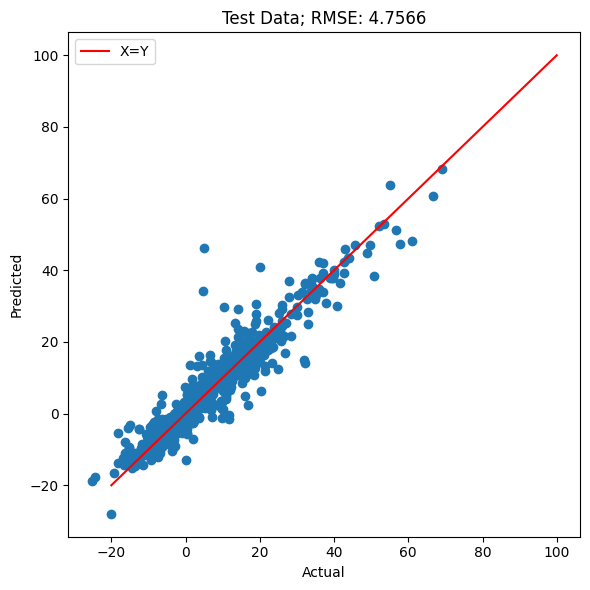

In [27]:
# Unpack the results
best_model = neurnet.train_model_kfold(
    fprints,
    target,
    model,
    criterion=None,
    optimiser_class=None,
    test_split_size=0.2,
    num_epochs=500,
    k=5,
    batch_size=64,
    learn_rate=5e-4,
    weight_decay=1e-4,
    patience=25,
    style='scatter',
    limits=[-20, 100]
)

**EXTRACT DESCRIPTOR INFORMATION**

In [28]:
from skfp.fingerprints import MordredFingerprint
from rdkit import Chem

mfp = MordredFingerprint()
mol = Chem.MolFromSmiles(gen["smiles"][0])
mfp.fit([mol])  # mols = your list of RDKit mol objects
descriptor_names = mfp.get_feature_names_out()

In [29]:
descriptor_names

array(['ABC', 'ABCGG', 'nAcid', ..., 'Zagreb2', 'mZagreb1', 'mZagreb2'],
      shape=(1613,), dtype=object)

In [30]:
# check num of descripters match columns in fingerprints
print(f"Feature names: {len(descriptor_names)}")
print(f"Columns in fprints: {fprints.shape[1]}")

Feature names: 1613
Columns in fprints: 1613


In [ ]:
import shap
import torch

model.eval()

descriptor_names = mfp.get_feature_names_out()
assert len(descriptor_names) == fprints.shape[1], "Name count doesn't match features!"

# GradientExplainer
background_tensor = torch.tensor(fprints, dtype=torch.float32)
explainer = shap.GradientExplainer(model, background_tensor)

test_tensor = torch.tensor(fprints, dtype=torch.float32)
shap_values = explainer.shap_values(test_tensor)


shap_values = np.array(shap_values).squeeze(axis=-1)
print(f"Squeezed shape: {shap_values.shape}")  # Should be (10, 1613)

# plot
shap.summary_plot(shap_values, fprints, feature_names=descriptor_names)